In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
from sklearn.linear_model import LinearRegression
import json
from scipy.signal import savgol_filter

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

In [2]:
tpc_paths = [
    '../results/tpc/Apr-10-2025-11-08-20', 
    '../results/tpc/Nov-15-2025-12-40-19', 
    '../results/tpc/Nov-15-2025-13-44-35', 
    # '../results/tpc/Nov-08-2025-22-23-31'
]
# rnn_paths = ['../results/rnn/May-03-2025-14-46-21', '../results/rnn/May-03-2025-14-46-21', '../results/rnn/May-03-2025-14-46-21']
rnn_paths = [
    '../results/rnn/May-03-2025-14-46-21', 
    '../results/rnn/Nov-15-2025-12-41-53', 
    '../results/rnn/Nov-15-2025-12-47-45',
    # '../results/rnn/Nov-08-2025-23-06-16'
]

In [3]:
# Cell-style figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'black',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'legend.frameon': False
})

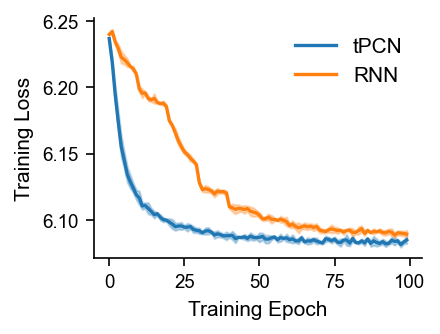

In [4]:
tpc_losses = np.array([np.load(os.path.join(tpc_paths[i], 'loss.npy')) for i in range(len(tpc_paths))])
rnn_losses = np.array([np.load(os.path.join(rnn_paths[i], 'loss.npy')) for i in range(len(rnn_paths))])


fig, ax = plt.subplots(figsize=(3, 2.3))

ax.plot(tpc_losses.mean(axis=0), label='tPCN', color='C0', lw=1.6)
ax.plot(rnn_losses.mean(axis=0), label='RNN', color='C1', lw=1.6)
# plot std
ax.fill_between(np.arange(tpc_losses.shape[1]), 
                tpc_losses.mean(axis=0) - tpc_losses.std(axis=0), 
                tpc_losses.mean(axis=0) + tpc_losses.std(axis=0), 
                color='C0', alpha=0.3)
ax.fill_between(np.arange(rnn_losses.shape[1]), 
                rnn_losses.mean(axis=0) - rnn_losses.std(axis=0), 
                rnn_losses.mean(axis=0) + rnn_losses.std(axis=0), 
                color='C1', alpha=0.3)

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

ax.set_xlabel('Training Epoch', fontsize=10)
ax.set_ylabel('Training Loss', fontsize=10)

# Legend styling consistent with Cell figures
ax.legend(loc='upper right', fontsize=10, ncol=1)

# Tidy layout and save
plt.tight_layout()
plt.savefig('../results/learning/loss_cell.pdf', bbox_inches='tight')
plt.show()

In [7]:
import numpy as np

def time_to_threshold(losses, threshold, k=1):
    """
    losses: (n_runs, n_epochs)
    threshold: scalar
    k: number of consecutive epochs required below threshold
    returns: (n_runs,) time-to-threshold (0-based epoch index)
             returns n_epochs if never reached
    """
    n_runs, n_epochs = losses.shape
    t = np.full(n_runs, n_epochs, dtype=int)

    for i in range(n_runs):
        below = losses[i] <= threshold
        for e in range(n_epochs - k + 1):
            if below[e:e+k].all():
                t[i] = e
                break
    return t

# ----- compute global threshold (75% of pooled improvement) -----
pooled = np.vstack([rnn_losses, tpc_losses])

L_init  = np.median(pooled[:, 0])
L_final = np.median(pooled[:, -1])
threshold = L_final + 0.75 * (L_init - L_final)

# ----- compute time-to-threshold -----
t_rnn = time_to_threshold(rnn_losses, threshold, k=2)
t_tpc = time_to_threshold(tpc_losses, threshold, k=2)

print(f"Threshold = {threshold:.4f}")
print("t_rnn:", t_rnn, "mean:", t_rnn.mean(), t_rnn.std())
print("t_tpc:", t_tpc, "mean:", t_tpc.mean(), t_tpc.std())


Threshold = 6.2008
t_rnn: [11 10 10] mean: 10.333333333333334 0.4714045207910317
t_tpc: [2 3 2] mean: 2.3333333333333335 0.4714045207910317


In [8]:
from scipy.stats import ttest_ind

t_stat, p = ttest_ind(t_tpc, t_rnn, equal_var=False, alternative="less")
print("Welch t-test p-value:", p)

Welch t-test p-value: 3.5346748432512515e-05


In [9]:
# get the final grid scores for each model
def get_final_grid_scores(model_path):
    final_scores = np.load(os.path.join(model_path, 'grid_scores/grid_scores_epoch_100.npy'))
    return final_scores

# calculate the average grid score across epochs for each model
def calculate_avg_grid_scores(model_path):
    grid_scores = []
    for e in range(0, 102, 2):
        score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
        grid_scores.append(score)
    grid_scores = np.array(grid_scores)  # shape (num_epochs, num_cells)
    avg_grid_scores = np.mean(grid_scores, axis=0)  # shape (num_cells,)
    return avg_grid_scores

# get the cumulative percentage of cells (among those with the highest average scores) that have reached >= 95% of their final grid score
def calculate_cumulative_percentage(model_path, sorted_indices, percent_of_final=0.95, top_k=128):
    num_cells = len(sorted_indices)
    cumulative_percentages = []

    for e in range(0, 102, 2):
        score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
        top_k_indices = sorted_indices[-top_k:]
        count_reached = 0

        for idx in top_k_indices:
            final_score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_100.npy'))[idx]
            if score[idx] >= percent_of_final * final_score:
                count_reached += 1

        cumulative_percentage = (count_reached / top_k) * 100
        cumulative_percentages.append(cumulative_percentage)

    return cumulative_percentages

In [10]:
metric = 'final' # 'avg' or 'final'; if we use avg, the cells we choose are already the fastest learners of gridness
percent_of_final = 0.5
top_k = 64

tpc_accumulative_percentages = []
tpc_top_scores = []
for tpc_path in tpc_paths:
    if metric == 'final':
        metric_grid_scores = get_final_grid_scores(tpc_path)
    else:
        metric_grid_scores = calculate_avg_grid_scores(tpc_path)
    sorted_indices = np.argsort(metric_grid_scores)
    tpc_top_scores.append(metric_grid_scores[sorted_indices[-top_k:]])
    cumulative_percentages = calculate_cumulative_percentage(tpc_path, sorted_indices, percent_of_final=percent_of_final, top_k=top_k)
    tpc_accumulative_percentages.append(cumulative_percentages)
tpc_accumulative_percentages = np.array(tpc_accumulative_percentages)

rnn_accumulative_percentages = []
rnn_top_scores = []
for rnn_path in rnn_paths:
    if metric == 'final':
        metric_grid_scores = get_final_grid_scores(rnn_path)
    else:
        metric_grid_scores = calculate_avg_grid_scores(rnn_path)
    sorted_indices = np.argsort(metric_grid_scores)
    rnn_top_scores.append(metric_grid_scores[sorted_indices[-top_k:]])
    cumulative_percentages = calculate_cumulative_percentage(rnn_path, sorted_indices, percent_of_final=percent_of_final, top_k=top_k)
    rnn_accumulative_percentages.append(cumulative_percentages)
rnn_accumulative_percentages = np.array(rnn_accumulative_percentages)


In [18]:
import numpy as np
from scipy.stats import ttest_ind

def time_to_threshold_from_curve(acc_pct, threshold=100.0, k=1):
    """
    acc_pct: (n_runs, E) cumulative percentages (0..100)
    threshold: 100.0 means all cells have reached the criterion
    k: require k consecutive epochs >= threshold
    returns: (n_runs,) 0-based epoch index; E if never reached
    """
    acc_pct = np.asarray(acc_pct, dtype=float)
    n_runs, E = acc_pct.shape
    t = np.full(n_runs, E, dtype=int)

    for i in range(n_runs):
        above = acc_pct[i] >= threshold
        for e in range(E - k + 1):
            if above[e:e+k].all():
                t[i] = e
                break
    return t

# ---- compute time-to-100% ----
t_rnn = time_to_threshold_from_curve(rnn_accumulative_percentages, threshold=75.0, k=1)
t_tpc = time_to_threshold_from_curve(tpc_accumulative_percentages, threshold=75.0, k=1)

# Welch t-test (one-sided): tPC faster => smaller time
res = ttest_ind(t_tpc, t_rnn, equal_var=False, alternative="less")

print("Time until 75% of cells reached 50% of final grid score:")
print("t_rnn:", t_rnn, "mean:", t_rnn.mean(), "std:", t_rnn.std(ddof=1))
print("t_tpc:", t_tpc, "mean:", t_tpc.mean(), "std:", t_tpc.std(ddof=1))
print("Welch t-test p-value (tPC faster):", res.pvalue)


Time until 75% of cells reached 50% of final grid score:
t_rnn: [17 16 16] mean: 16.333333333333332 std: 0.5773502691896258
t_tpc: [ 7 10  9] mean: 8.666666666666666 std: 1.5275252316519468
Welch t-test p-value (tPC faster): 0.003398498661515097


In [11]:
np.mean(tpc_top_scores), np.std(tpc_top_scores), np.mean(rnn_top_scores), np.std(rnn_top_scores)

(1.0337551676561874,
 0.11472601294073899,
 0.9864988145337833,
 0.1359301904558211)

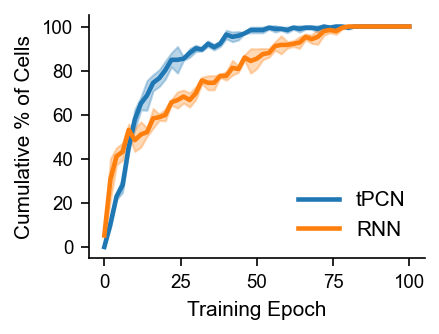

In [8]:
# plot cumulative percentages with shaded error bars
x = np.arange(0, 102, 2)
fig, ax = plt.subplots(figsize=(3, 2.3))
ax.plot(x, tpc_accumulative_percentages.mean(axis=0), label='tPCN', color='C0', lw=2.2)
ax.plot(x, rnn_accumulative_percentages.mean(axis=0), label='RNN', color='C1', lw=2.2)
# plot std
ax.fill_between(x, 
                tpc_accumulative_percentages.mean(axis=0) - tpc_accumulative_percentages.std(axis=0), 
                tpc_accumulative_percentages.mean(axis=0) + tpc_accumulative_percentages.std(axis=0), 
                color='C0', alpha=0.3)
ax.fill_between(x, 
                rnn_accumulative_percentages.mean(axis=0) - rnn_accumulative_percentages.std(axis=0), 
                rnn_accumulative_percentages.mean(axis=0) + rnn_accumulative_percentages.std(axis=0), 
                color='C1', alpha=0.3)
# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

ax.set_xlabel('Training Epoch', fontsize=10)
ax.set_ylabel('Cumulative % of Cells', fontsize=10)

# Legend styling consistent with Cell figures
ax.legend(fontsize=10, ncol=1)
ax.set_xticks(np.arange(0, 102, 25))
# Tidy layout and save
plt.tight_layout()
plt.savefig('../results/learning/cumulative_percentage_cell.pdf', bbox_inches='tight')
plt.show()

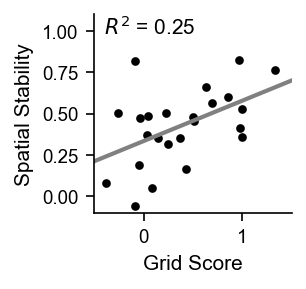

In [19]:
rat_y = [-0.05569620253164557, 0.08354430379746836, 0.05063291139240506, 0.19240506329113924, 
0.16835443037974684, 0.3177215189873418, 0.3531645569620253, 0.35443037974683544, 
0.3708860759493671, 0.4835443037974684, 0.4746835443037975, 0.5037974683544304, 
0.5050632911392405, 0.4569620253164557, 0.47848101265822784, 0.4126582278481013, 
0.35822784810126584, 0.5303797468354431, 0.5987341772151898, 0.5632911392405063, 
0.660759493670886, 0.8278481012658228, 0.7645569620253164, 0.8202531645569621]
rat_x = [-0.08660844250363897, -0.38064046579330424, 0.08515283842794763, -0.051673944687045115, 
0.43449781659388653, 0.24526928675400295, 0.3646288209606987, 0.14919941775836976, 
0.029839883551673996, 0.04148471615720528, -0.03711790393013098, -0.2583697234352256, 
0.23071324599708887, 0.5131004366812228, 0.5043668122270744, 0.9818049490538574, 
0.9934497816593888, 0.9934497816593888, 0.8537117903930131, 0.6906841339155749, 
0.6353711790393013, 0.9672489082969433, 1.336972343522562, -0.08660844250363897]

# fit a line to the rat data
lr = LinearRegression()
rat_x_reshaped = np.array(rat_x).reshape(-1, 1)
lr.fit(rat_x_reshaped, rat_y)
rat_fit_x = np.linspace(-0.5, 1.5, 100).reshape(-1, 1)
rat_fit_y = lr.predict(rat_fit_x)
# r^2
r2 = lr.score(rat_x_reshaped, rat_y)


fig, ax = plt.subplots(figsize=(2.2,2))
ax.scatter(rat_x, rat_y, color='black', s=10)
ax.plot(rat_fit_x, rat_fit_y, color='gray', lw=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.text(0.05, 0.9, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, fontsize=10)

ax.set_xlabel('Grid Score', fontsize=10)
ax.set_ylabel('Spatial Stability', fontsize=10)

ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.1, 1.1])
plt.tight_layout()
plt.savefig('../results/learning/rat_data_fit.pdf', bbox_inches='tight')
plt.show()

In [20]:
# measure spatial stability within epoch ranges [1,20], [21,40], [41,60], [61,80], [81,100]
# as the correlation between the rate maps of the same cell at the end of the two halves of the epoch
# define interval ranges
metric = 'final' # 'avg' or 'final'; if we use avg, the cells we choose are already the fastest learners of gridness
n_cells = 16
n_intervals = 10
interval_size = 80 // n_intervals
intervals = [(i, i + interval_size) for i in range(0, n_intervals * interval_size, interval_size)]
print("Intervals:", intervals)
stability_results = {'tPCN': [], 'RNN': []}
score_results = {'tPCN': [], 'RNN': []}
for model_name, model_paths in zip(['tPCN', 'RNN'], [tpc_paths, rnn_paths]):
    for model_path in model_paths:
        if metric == 'final':
            metric_grid_scores = get_final_grid_scores(model_path)
        else:
            metric_grid_scores = calculate_avg_grid_scores(model_path)
        top_n_cells = np.argsort(metric_grid_scores)[-n_cells:]
        model_stabilities = []
        model_scores = []
        for start_epoch, end_epoch in intervals:
            mid_epoch = (start_epoch + end_epoch) // 2
            rate_maps_first_half = np.load(os.path.join(model_path, f'rate_maps_epoch/rate_map_epoch_{mid_epoch}.npy'))[top_n_cells]
            rate_maps_second_half = np.load(os.path.join(model_path, f'rate_maps_epoch/rate_map_epoch_{end_epoch}.npy'))[top_n_cells]
            # also compute the grid scores of these cells at these epochs
            # grid_score_start = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{start_epoch-1}.npy'))[top_n_cells]
            grid_score_first_half = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{mid_epoch}.npy'))[top_n_cells]
            grid_score_second_half = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{end_epoch}.npy'))[top_n_cells]
            # compute stability as correlation between rate maps
            num_cells = rate_maps_first_half.shape[0]
            cell_stabilities = []
            cell_grid_scores = []
            for cell_idx in range(num_cells):
                map_first = rate_maps_first_half[cell_idx].flatten()
                map_second = rate_maps_second_half[cell_idx].flatten()
                if np.std(map_first) == 0 or np.std(map_second) == 0:
                    corr = 0
                else:
                    corr = np.corrcoef(map_first, map_second)[0, 1]
                cell_stabilities.append(corr)
                cell_grid_scores.append(grid_score_first_half[cell_idx])
            model_stabilities.append(cell_stabilities)
            model_scores.append(cell_grid_scores)
        model_stabilities = np.array(model_stabilities)  # shape (num_intervals, num_cells)
        model_scores = np.array(model_scores)  # shape (num_intervals, num_cells)
        score_results[model_name].append(model_scores)
        stability_results[model_name].append(model_stabilities)

Intervals: [(0, 8), (8, 16), (16, 24), (24, 32), (32, 40), (40, 48), (48, 56), (56, 64), (64, 72), (72, 80)]


In [21]:
score_results['tPCN'] = np.array(score_results['tPCN'])  # shape (num_models, num_intervals, num_cells)
score_results['RNN'] = np.array(score_results['RNN'])
stability_results['tPCN'] = np.array(stability_results['tPCN'])
stability_results['RNN'] = np.array(stability_results['RNN'])
stability_results['tPCN'].shape

(3, 10, 16)

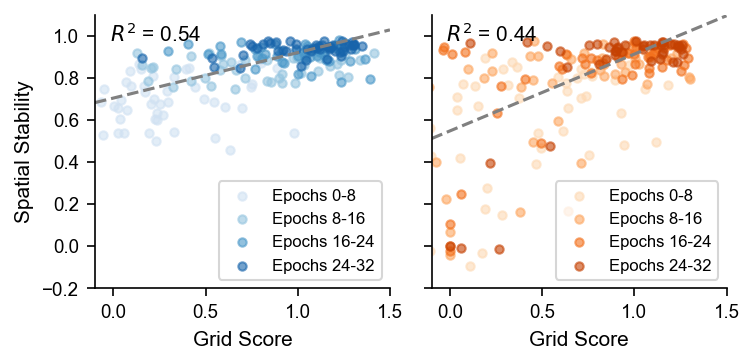

In [22]:
# now for each model, plot stability vs grid score for all cells, with scatter plot color by interval
# color by shades of C0 for tPCN and C1 for RNN
from sklearn.linear_model import LinearRegression
selected_intervals = intervals[:4]
blues = plt.get_cmap('Blues')(np.linspace(0.2, 0.8, len(selected_intervals)))
oranges = plt.get_cmap('Oranges')(np.linspace(0.2, 0.8, len(selected_intervals)))

fig, axes = plt.subplots(1, 2, figsize=(5.1, 2.5), sharey=True)

for idx, model_name in enumerate(['tPCN', 'RNN']):
    ax = axes[idx]
    color_map = blues if model_name == 'tPCN' else oranges
    
    for interval_idx, (start_epoch, end_epoch) in enumerate(selected_intervals):
        all_scores = score_results[model_name][:, interval_idx, :].flatten()
        all_stabilities = stability_results[model_name][:, interval_idx, :].flatten()
        ax.scatter(all_scores, all_stabilities, label=f'Epochs {start_epoch}-{end_epoch}', 
                   alpha=0.6, s=16, color=color_map[interval_idx])

    # fit linear regression line with r^2 value
    all_scores = score_results[model_name].reshape(-1)
    all_stabilities = stability_results[model_name].reshape(-1)
    lr_model = LinearRegression()
    lr_model.fit(all_scores.reshape(-1, 1), all_stabilities)
    x_vals = np.array([-0.1, 1.5])
    y_vals = lr_model.predict(x_vals.reshape(-1, 1))
    r2 = lr_model.score(all_scores.reshape(-1, 1), all_stabilities)
    ax.plot(x_vals, y_vals, color='gray', linestyle='--')
    
    # Clean axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    ax.set_xlabel('Grid Score', fontsize=10)
    if idx == 0:
        ax.set_ylabel('Spatial Stability', fontsize=10)
    # ax.set_title(model_name, fontsize=10)

    ax.set_xlim([-0.1, 1.5])
    ax.set_ylim([-0.2, 1.1])

    ax.text(0.05, 0.9, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, fontsize=10)
    ax.legend(fontsize=8, ncol=1, frameon=True, loc='lower right')

plt.tight_layout()
plt.savefig(f'../results/learning/stability_vs_grid_score_cell.pdf', bbox_inches='tight')
plt.show()

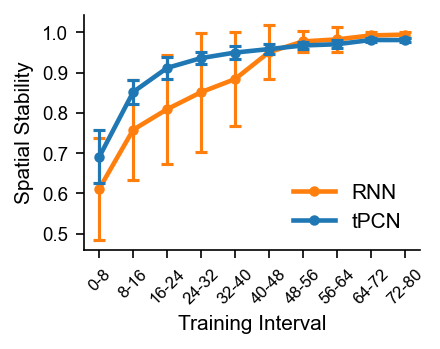

In [23]:
# plot the evolution of stability vs interval index with vertical lines for std
fig, ax = plt.subplots(figsize=(3, 2.4))
for model_name, color in zip(['RNN', 'tPCN'], ['C1', 'C0']):
    mean_stabilities = stability_results[model_name].mean(axis=0).mean(axis=1)  # shape (num_intervals,)
    std_stabilities = stability_results[model_name].mean(axis=0).std(axis=1)
    ax.plot(range(len(intervals)), mean_stabilities, label=model_name, color=color, lw=2.2, marker='o', markersize=4)
    # draw error bars with caps
    ax.errorbar(range(len(intervals)), mean_stabilities, yerr=std_stabilities,
                color=color, alpha=1, fmt='none', capsize=3, capthick=1.5, elinewidth=1.5)

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.set_xlabel('Training Interval', fontsize=10)
ax.set_ylabel('Spatial Stability', fontsize=10)
ax.set_xticks(range(len(intervals)))
ax.set_xticklabels([f'{start}-{end}' for start, end in intervals], rotation=45, fontsize=8)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig('../results/learning/stability_vs_interval_cell.pdf', bbox_inches='tight')
plt.show()

In [31]:
import numpy as np
from scipy.stats import levene

tpc = stability_results['tPCN']  # (3, 10, 16)
rnn = stability_results['RNN']   # (3, 10, 16)

n_intervals = tpc.shape[1]

var_tpc = np.zeros(n_intervals)
var_rnn = np.zeros(n_intervals)
p_values = np.zeros(n_intervals)

for t in range(n_intervals):
    # pool cells across runs -> 48 values per model
    tpc_cells = tpc[:, t, :].reshape(-1)
    rnn_cells = rnn[:, t, :].reshape(-1)

    var_tpc[t] = np.var(tpc_cells, ddof=1)
    var_rnn[t] = np.var(rnn_cells, ddof=1)

    # Levene test (Brown–Forsythe, median-centered)
    _, p = levene(tpc_cells, rnn_cells, center='median')
    p_values[t] = p

print("Interval | Var(tPCN) | Var(RNN) | Levene p-value")
for t in range(n_intervals):
    print(f"{t:8d} | {var_tpc[t]:9.4f} | {var_rnn[t]:8.4f} | {p_values[t]:.3e}")


Interval | Var(tPCN) | Var(RNN) | Levene p-value
       0 |    0.0135 |   0.0701 | 1.485e-03
       1 |    0.0029 |   0.0661 | 1.847e-03
       2 |    0.0021 |   0.0571 | 1.072e-02
       3 |    0.0010 |   0.0620 | 1.974e-02
       4 |    0.0007 |   0.0461 | 3.802e-02
       5 |    0.0007 |   0.0146 | 2.767e-01
       6 |    0.0002 |   0.0019 | 4.018e-01
       7 |    0.0003 |   0.0030 | 7.870e-01
       8 |    0.0001 |   0.0002 | 4.417e-01
       9 |    0.0001 |   0.0002 | 3.226e-01


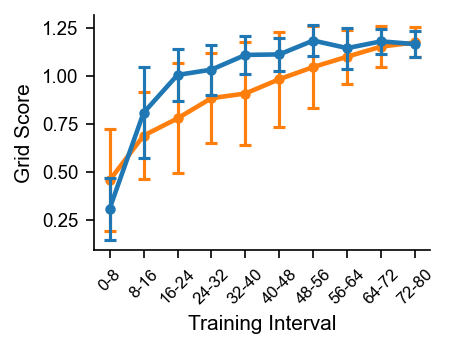

In [24]:
# plot evolution of grid score vs interval index with vertical lines for std
fig, ax = plt.subplots(figsize=(3, 2.4))
for model_name, color in zip(['RNN', 'tPCN'], ['C1', 'C0']):
    mean_scores = score_results[model_name].mean(axis=0).mean(axis=1)  # shape (num_intervals,)
    std_scores = score_results[model_name].mean(axis=0).std(axis=1)
    ax.plot(range(len(intervals)), mean_scores, label=model_name, color=color, lw=2.2, marker='o', markersize=4)
    # draw error bars with caps
    ax.errorbar(range(len(intervals)), mean_scores, yerr=std_scores,
                color=color, alpha=1, fmt='none', capsize=3, capthick=1.5, elinewidth=1.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Training Interval', fontsize=10)
# ax.set_ylabel('Spatial Stability', fontsize=10)
ax.set_ylabel('Grid Score', fontsize=10)
ax.set_xticks(range(len(intervals)))
ax.set_xticklabels([f'{start}-{end}' for start, end in intervals], rotation=45, fontsize=8)
plt.tight_layout()
plt.savefig('../results/learning/grid_score_vs_interval_cell.pdf', bbox_inches='tight')
plt.show()

In [33]:
import numpy as np
from scipy.stats import levene

tpc = score_results['tPCN']  # (3, 10, 16)
rnn = score_results['RNN']   # (3, 10, 16)

n_intervals = tpc.shape[1]

var_tpc = np.zeros(n_intervals)
var_rnn = np.zeros(n_intervals)
p_values = np.zeros(n_intervals)

for t in range(n_intervals):
    # pool cells across runs -> 48 values per model
    tpc_cells = tpc[:, t, :].reshape(-1)
    rnn_cells = rnn[:, t, :].reshape(-1)

    var_tpc[t] = np.var(tpc_cells, ddof=1)
    var_rnn[t] = np.var(rnn_cells, ddof=1)

    # Levene test (Brown–Forsythe, median-centered)
    _, p = levene(tpc_cells, rnn_cells, center='median')
    p_values[t] = p

print("Interval | Var(tPCN) | Var(RNN) | p (Levene) | p_FDR | signif")
for t in range(n_intervals):
    print(f"{t:8d} | {var_tpc[t]:9.4f} | {var_rnn[t]:8.4f} | {p_values[t]:9.3e}")


Interval | Var(tPCN) | Var(RNN) | p (Levene) | p_FDR | signif
       0 |    0.0810 |   0.1495 | 5.109e-03
       1 |    0.1212 |   0.1519 | 5.605e-01
       2 |    0.0627 |   0.1811 | 6.807e-03
       3 |    0.0600 |   0.1420 | 4.572e-02
       4 |    0.0397 |   0.1627 | 7.028e-03
       5 |    0.0180 |   0.1478 | 1.561e-02
       6 |    0.0133 |   0.0850 | 1.877e-02
       7 |    0.0206 |   0.0387 | 4.197e-01
       8 |    0.0095 |   0.0205 | 6.566e-01
       9 |    0.0103 |   0.0080 | 4.865e-01


Lower grid score with high stability - cells in rnn stopped making themselves more grid like while they are still not grid-like enough

Higher grid score with low stability - cells in rnn still changing themselves even when grid score is high, reducing their own grid scores.

In [15]:
# take cells indices with grid score < 0.4 but stability < 0.1 from RNN model
rnn_interesting_cells = []
for model_idx in range(score_results['RNN'].shape[0]):
    for interval_idx in range(score_results['RNN'].shape[1]):
        for cell_idx in range(score_results['RNN'].shape[2]):
            grid_score = score_results['RNN'][model_idx, interval_idx, cell_idx]
            stability = stability_results['RNN'][model_idx, interval_idx, cell_idx]
            if interval_idx == 3 and grid_score < 0.4 and stability < 0.1:
                rnn_interesting_cells.append((model_idx, interval_idx, cell_idx, grid_score, stability))

In [16]:
rnn_interesting_cells

[(0, 3, 0, 0.0, 0.0),
 (0, 3, 10, 0.2662184363782548, -0.013969886748814995),
 (1, 3, 15, 0.05761469637155711, -0.011535290085822365)]

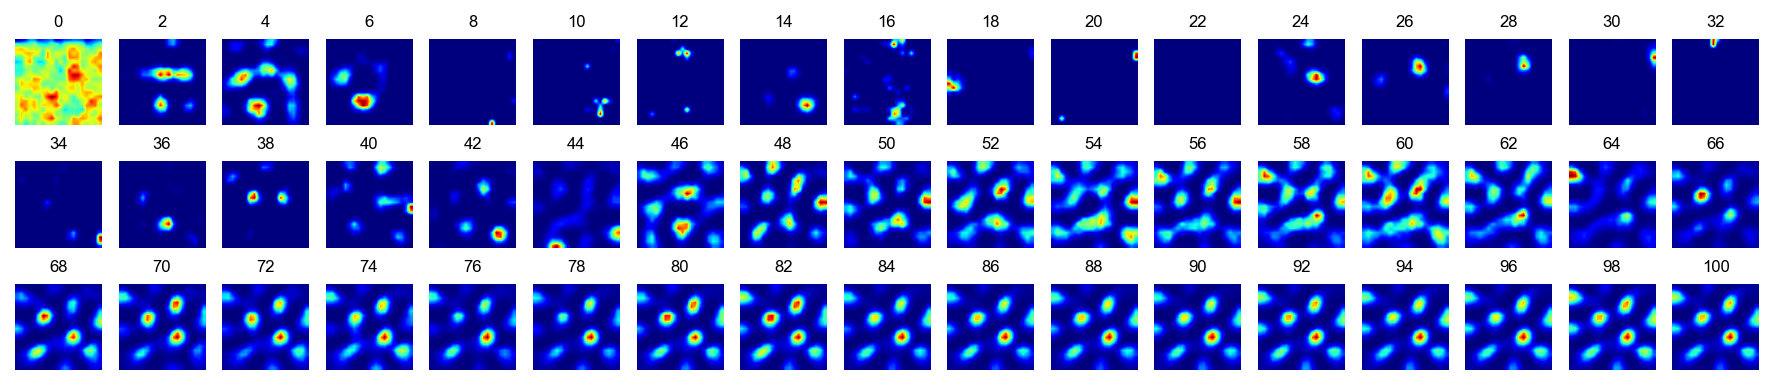

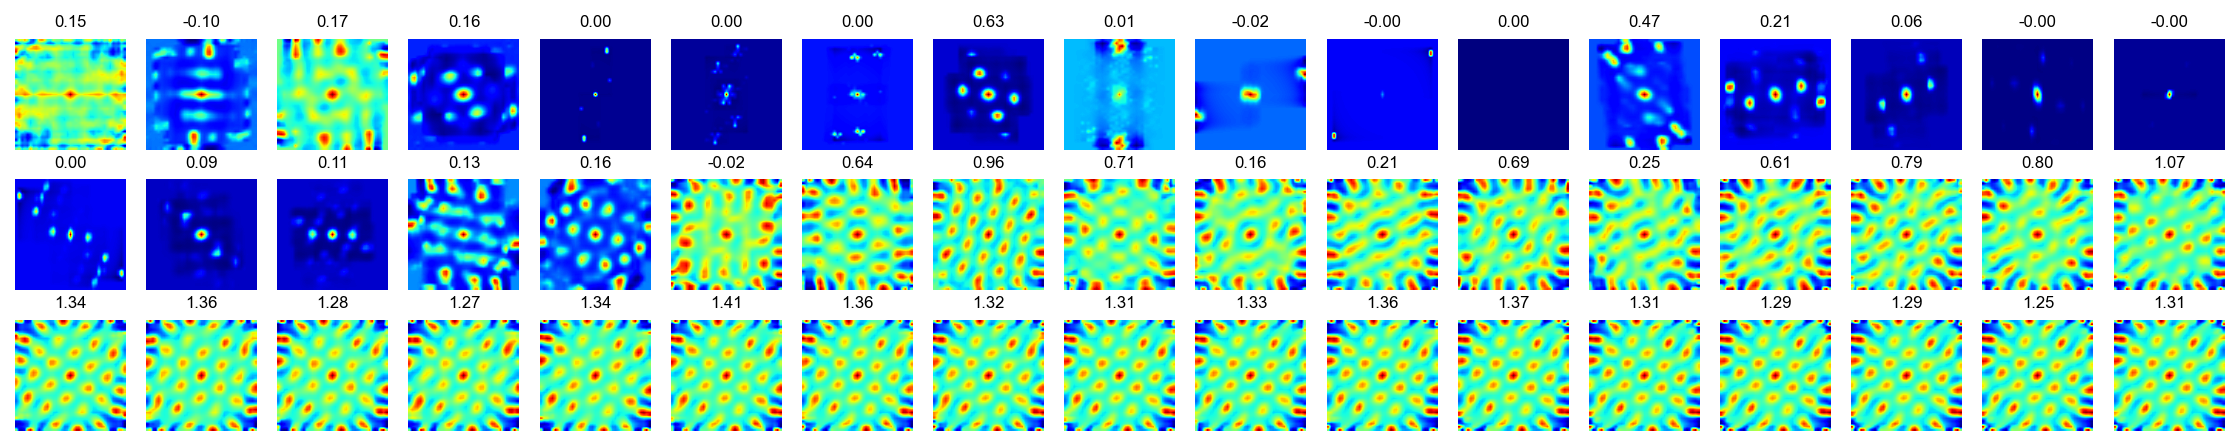

In [36]:
# Create 5x10 grids showing evolution of rate maps and SACs for all epochs
path_i, interval_i, cell_i, _, _ = rnn_interesting_cells[2]
path = rnn_paths[path_i]
if metric == 'final':
    metric_grid_scores = get_final_grid_scores(path)
else:
    metric_grid_scores = calculate_avg_grid_scores(path)
top_n_cells = np.argsort(metric_grid_scores)[-n_cells:]
cell_idx = top_n_cells[cell_i]

all_epochs = np.arange(0, 102, 2)  # all 51 epochs
n_rows, n_cols = 3, 17

# Plot rate maps
fig_rm, axes_rm = plt.subplots(n_rows, n_cols, figsize=(15, 3))
axes_rm = axes_rm.flatten()

# Plot SACs
fig_sac, axes_sac = plt.subplots(n_rows, n_cols, figsize=(15, 3))
axes_sac = axes_sac.flatten()

for idx, epoch in enumerate(all_epochs):
    rm = np.load(os.path.join(path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))[cell_idx]
    rm = (rm - rm.min()) / (rm.max() - rm.min() + 1e-8)
    sac = np.load(os.path.join(path, f'sacs/sacs_epoch_{epoch}.npy'))[cell_idx]
    sac = (sac - sac.min()) / (sac.max() - sac.min() + 1e-8)
    
    grid_score_epoch = np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{epoch}.npy'))[cell_idx]
    
    axes_rm[idx].imshow(rm, cmap='jet', interpolation='bilinear')
    axes_rm[idx].set_title(f'{epoch}', fontsize=8)
    axes_rm[idx].axis('off')
    
    axes_sac[idx].imshow(sac, cmap='jet', interpolation='bilinear')
    axes_sac[idx].set_title(f'{grid_score_epoch:.2f}', fontsize=8)
    axes_sac[idx].axis('off')

plt.tight_layout()
fig_rm.savefig(f'../results/learning/rate_maps_evolution_rnn_{path_i}_cell{cell_i}.pdf', bbox_inches='tight', dpi=100)

fig_sac.savefig(f'../results/learning/sacs_evolution_rnn_{path_i}_cell{cell_i}.pdf', bbox_inches='tight', dpi=100)
plt.show()


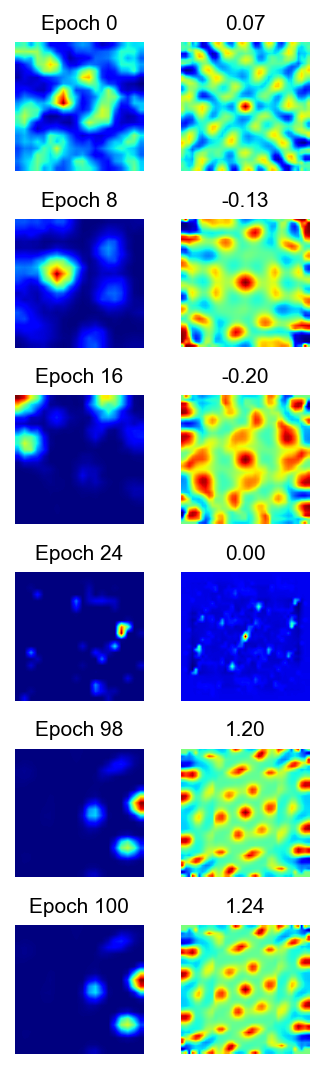

In [17]:
# visualize rate maps of these interesting cells in rnn (transposed subplots: rows = epochs, cols = [rm, sac])
path_i, interval_i, cell_i, _, _ = rnn_interesting_cells[1]
path = rnn_paths[path_i]
plot_epochs = np.arange(0, 32, 8)
interval_start, interval_end = intervals[interval_i]
interval_mid = (interval_start + interval_end) // 2
if metric == 'final':
    metric_grid_scores = get_final_grid_scores(path)
else:
    metric_grid_scores = calculate_avg_grid_scores(path)
top_n_cells = np.argsort(metric_grid_scores)[-n_cells:]
cell_idx = top_n_cells[cell_i]

# ensure epochs 98 and 100 are always included at the end
epochs_to_plot = list(plot_epochs)
for e in (98, 100):
    if e not in epochs_to_plot:
        epochs_to_plot.append(e)

n_epochs = len(epochs_to_plot)
fig, ax = plt.subplots(n_epochs, 2, figsize=(2 * 1.2, n_epochs * 1.2))
# if only one epoch, ensure ax is 2D-indexable
if n_epochs == 1:
    ax = ax.reshape(1, 2)

for j, epoch in enumerate(epochs_to_plot):
    rm = np.load(os.path.join(path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))[cell_idx]
    rm = (rm - rm.min()) / (rm.max() - rm.min() + 1e-8)
    sac = np.load(os.path.join(path, f'sacs/sacs_epoch_{epoch}.npy'))[cell_idx]
    sac = (sac - sac.min()) / (sac.max() - sac.min() + 1e-8)

    # load grid score for this cell at this epoch
    grid_score_epoch = np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{epoch}.npy'))[cell_idx]

    ax[j, 0].imshow(rm, cmap='jet', interpolation='bilinear')
    ax[j, 0].set_title(f'Epoch {epoch}', fontsize=10)               # RM title = epoch number
    ax[j, 1].imshow(sac, cmap='jet', interpolation='bilinear')
    ax[j, 1].set_title(f'{grid_score_epoch:.2f}', fontsize=10)  # SAC title = grid score

    ax[j, 0].axis('off')
    ax[j, 1].axis('off')

plt.tight_layout()
plt.savefig(f'../results/learning/interesting_cell_rnn_{path_i}_interval{interval_i}_cell{cell_i}.pdf', bbox_inches='tight')
plt.show()

In [25]:
# take cells indices with grid score < 0.4 but stability < 0.1 from tPCN model
tpcn_interesting_cells = []
for model_idx in range(score_results['tPCN'].shape[0]):
    for interval_idx in range(score_results['tPCN'].shape[1]):
        for cell_idx in range(score_results['tPCN'].shape[2]):
            grid_score = score_results['tPCN'][model_idx, interval_idx, cell_idx]
            stability = stability_results['tPCN'][model_idx, interval_idx, cell_idx]
            if interval_idx == 3 and grid_score > 1 and stability > 0.8:
                tpcn_interesting_cells.append((model_idx, interval_idx, cell_idx, grid_score, stability))

In [26]:
tpcn_interesting_cells  

[(0, 3, 1, 1.0702430441762183, 0.9266954579998979),
 (0, 3, 2, 1.1820022407569277, 0.9444744472112188),
 (0, 3, 4, 1.0988004956508102, 0.956370191311196),
 (0, 3, 5, 1.1885972941537912, 0.9543899064887595),
 (0, 3, 9, 1.140066812012672, 0.9722336449239202),
 (0, 3, 10, 1.2319785986838865, 0.9035566052286274),
 (0, 3, 12, 1.2449873365417863, 0.9252408987087468),
 (0, 3, 14, 1.0435480918717384, 0.8840517805037768),
 (0, 3, 15, 1.2990964348680907, 0.9571793622281458),
 (1, 3, 0, 1.1027592982909893, 0.940897359765957),
 (1, 3, 1, 1.080608065389595, 0.9411679101049728),
 (1, 3, 2, 1.251643127916953, 0.9478717238152572),
 (1, 3, 3, 1.2881157808940218, 0.9376110922681464),
 (1, 3, 4, 1.0507329590130388, 0.9365943327915284),
 (1, 3, 5, 1.1329981609693125, 0.9557130853168625),
 (1, 3, 6, 1.200313318133147, 0.9242024080842918),
 (1, 3, 7, 1.1206296149295272, 0.9367433328683703),
 (1, 3, 10, 1.2923070716809275, 0.9695697110260761),
 (1, 3, 13, 1.3056876204772396, 0.9554628723410323),
 (1, 3, 14, 

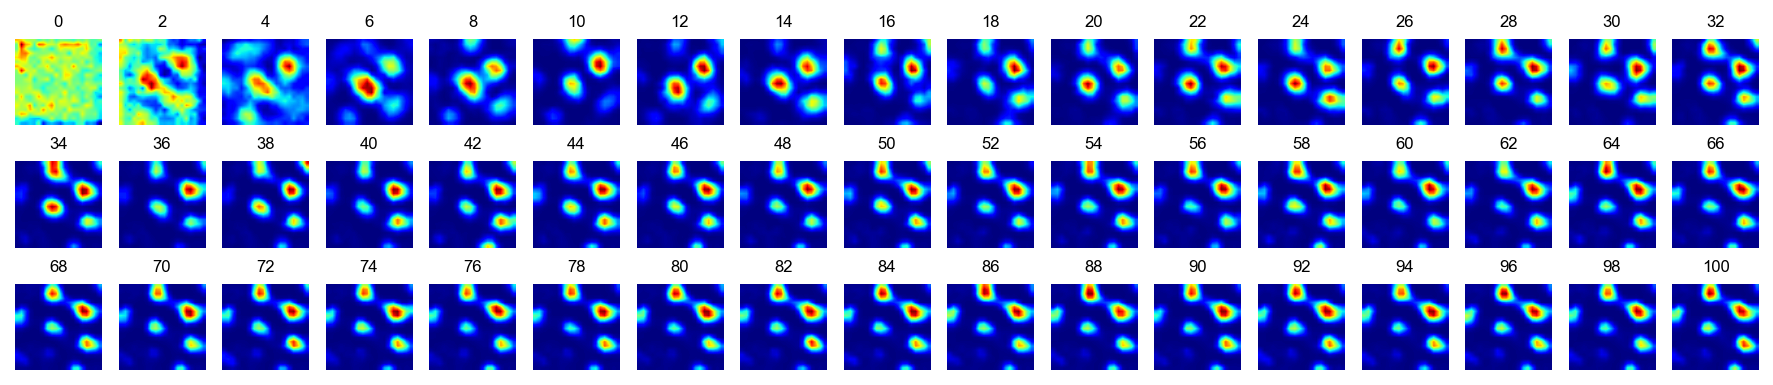

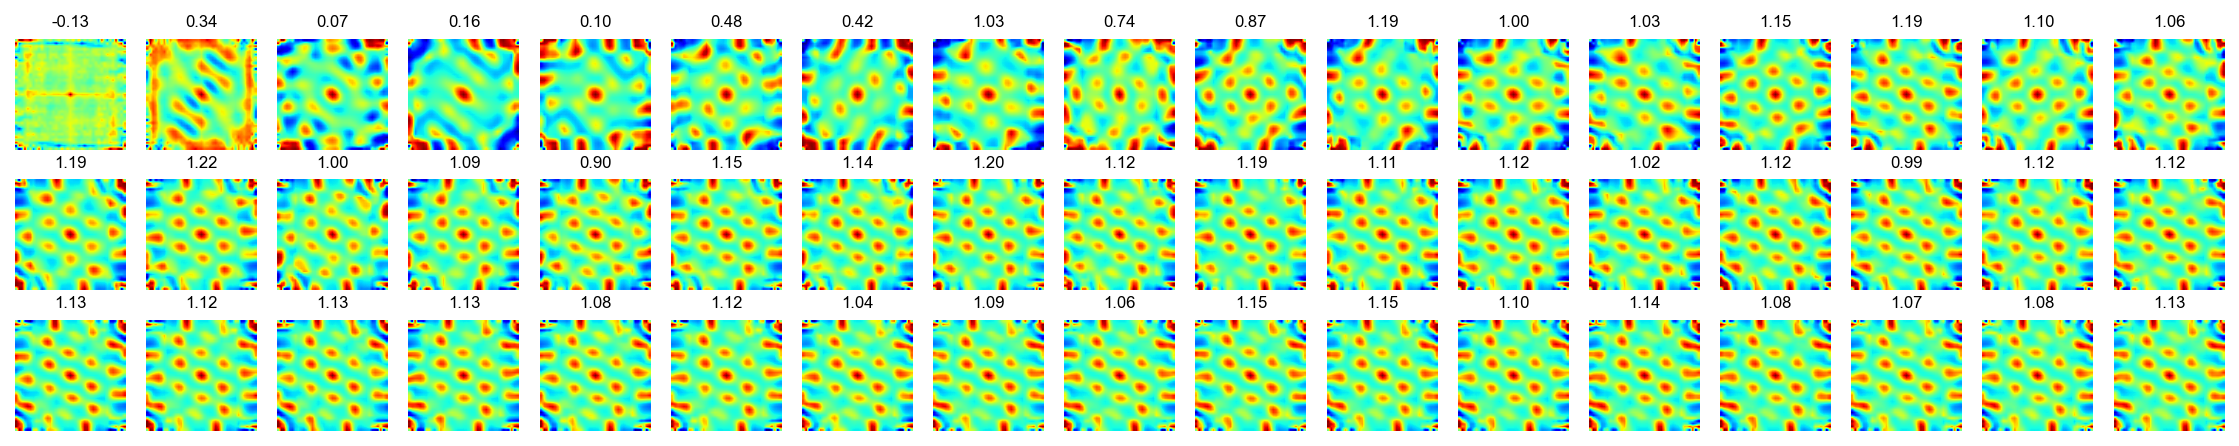

In [33]:
# Create 5x10 grids showing evolution of rate maps and SACs for all epochs
path_i, interval_i, cell_i, _, _ = tpcn_interesting_cells[3]
path = tpc_paths[path_i]
if metric == 'final':
    metric_grid_scores = get_final_grid_scores(path)
else:
    metric_grid_scores = calculate_avg_grid_scores(path)
top_n_cells = np.argsort(metric_grid_scores)[-n_cells:]
cell_idx = top_n_cells[cell_i]

all_epochs = np.arange(0, 102, 2)  # all 51 epochs
n_rows, n_cols = 3, 17

# Plot rate maps
fig_rm, axes_rm = plt.subplots(n_rows, n_cols, figsize=(15, 3))
axes_rm = axes_rm.flatten()

# Plot SACs
fig_sac, axes_sac = plt.subplots(n_rows, n_cols, figsize=(15, 3))
axes_sac = axes_sac.flatten()

for idx, epoch in enumerate(all_epochs):
    rm = np.load(os.path.join(path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))[cell_idx]
    rm = (rm - rm.min()) / (rm.max() - rm.min() + 1e-8)
    sac = np.load(os.path.join(path, f'sacs/sacs_epoch_{epoch}.npy'))[cell_idx]
    sac = (sac - sac.min()) / (sac.max() - sac.min() + 1e-8)
    
    grid_score_epoch = np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{epoch}.npy'))[cell_idx]
    
    axes_rm[idx].imshow(rm, cmap='jet', interpolation='bilinear')
    axes_rm[idx].set_title(f'{epoch}', fontsize=8)
    axes_rm[idx].axis('off')
    
    axes_sac[idx].imshow(sac, cmap='jet', interpolation='bilinear')
    axes_sac[idx].set_title(f'{grid_score_epoch:.2f}', fontsize=8)
    axes_sac[idx].axis('off')

plt.tight_layout()
fig_rm.savefig(f'../results/learning/rate_maps_evolution_tpcn_{path_i}_cell{cell_i}.pdf', bbox_inches='tight', dpi=100)

fig_sac.savefig(f'../results/learning/sacs_evolution_tpcn_{path_i}_cell{cell_i}.pdf', bbox_inches='tight', dpi=100)
plt.show()


In [ ]:
# visualize rate maps of these interesting cells in rnn (transposed subplots: rows = epochs, cols = [rm, sac])
path_i, interval_i, cell_i, _, _ = tpcn_interesting_cells[6]
path = tpc_paths[path_i]
plot_epochs = np.arange(0, 32, 8)
interval_start, interval_end = intervals[interval_i]
interval_mid = (interval_start + interval_end) // 2
if metric == 'final':
    metric_grid_scores = get_final_grid_scores(path)
else:
    metric_grid_scores = calculate_avg_grid_scores(path)
top_n_cells = np.argsort(metric_grid_scores)[-n_cells:]
cell_idx = top_n_cells[cell_i]

# ensure epochs 98 and 100 are always included at the end
epochs_to_plot = list(plot_epochs)
for e in (98, 100):
    if e not in epochs_to_plot:
        epochs_to_plot.append(e)

n_epochs = len(epochs_to_plot)
fig, ax = plt.subplots(n_epochs, 2, figsize=(2 * 1.2, n_epochs * 1.2))
# if only one epoch, ensure ax is 2D-indexable
if n_epochs == 1:
    ax = ax.reshape(1, 2)

for j, epoch in enumerate(epochs_to_plot):
    rm = np.load(os.path.join(path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))[cell_idx]
    rm = (rm - rm.min()) / (rm.max() - rm.min() + 1e-8)
    sac = np.load(os.path.join(path, f'sacs/sacs_epoch_{epoch}.npy'))[cell_idx]
    sac = (sac - sac.min()) / (sac.max() - sac.min() + 1e-8)

    # load grid score for this cell at this epoch
    grid_score_epoch = np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{epoch}.npy'))[cell_idx]

    ax[j, 0].imshow(rm, cmap='jet', interpolation='bilinear')
    ax[j, 0].set_title(f'Epoch {epoch}', fontsize=10)               # RM title = epoch number
    ax[j, 1].imshow(sac, cmap='jet', interpolation='bilinear')
    ax[j, 1].set_title(f'{grid_score_epoch:.2f}', fontsize=10)  # SAC title = grid score

    ax[j, 0].axis('off')
    ax[j, 1].axis('off')

plt.tight_layout()
plt.savefig(f'../results/learning/interesting_cell_tpcn_{path_i}_interval{interval_i}_cell{cell_i}.pdf', bbox_inches='tight')
plt.show()

NameError: name 'tpcn_paths' is not defined